# CNN evaluation HDF5 demo

This notebook evaluates CNN prediction files generated by:

```bash
python cbc_pe/scripts/train_cnn_hdf5.py --config <config.json>
```

The current goal is to compare candidate CNN architectures trained on the 100k HDF5 dataset using the 80/20 train/validation split.

This notebook focuses on:

- global validation metrics
- per-label validation metrics
- standardized-space metrics
- physical-space metrics
- absolute-error quantiles
- detailed diagnostics for a selected model

In [ ]:
from pathlib import Path
import os
import sys
import json

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()

# Allow running either from repository root or from cbc_pe/.
if PROJECT_ROOT.name != "cbc_pe" and (PROJECT_ROOT / "cbc_pe").exists():
    PROJECT_ROOT = PROJECT_ROOT / "cbc_pe"

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Main data root for CIEMAT/local office workflow.
DATA_ROOT = Path("/data/vserrano/cbc_pe_data")

DATA_PROCESSED = DATA_ROOT / "processed"
DATA_RESULTS = DATA_ROOT / "results"
DATA_MODELS = DATA_ROOT / "models"

dataset_id = "bbh_processed_4s_seobnrv4opt_snr10-25_n100_000"
MODEL_RESULTS_DIR = DATA_RESULTS / dataset_id

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("DATA_PROCESSED:", DATA_PROCESSED)
print("MODEL_RESULTS_DIR:", MODEL_RESULTS_DIR)
print("MODEL_RESULTS_DIR exists:", MODEL_RESULTS_DIR.exists())

## Register models to compare

Add one entry per trained model.

When a new model finishes training, add its prediction file to `prediction_files` and re-run the comparison cells.

In [ ]:
prediction_files = {
    "M00_baseline_emb64_seed123": MODEL_RESULTS_DIR / (
        "bbh_processed_4s_seobnrv4opt_snr10-25_n100_000"
        "_SimpleCNN_Baseline_M00_simple_emb64_mse_MSELoss_seed123"
        "_train_val_predictions_embeddings.npz"
    ),
    "M00_baseline_emb64_seed124": MODEL_RESULTS_DIR / (
        "bbh_processed_4s_seobnrv4opt_snr10-25_n100_000"
        "_SimpleCNN_Baseline_M00_simple_emb64_mse_MSELoss_seed124"
        "_train_val_predictions_embeddings.npz"
    ),
    "M00_baseline_emb64_seed125": MODEL_RESULTS_DIR / (
        "bbh_processed_4s_seobnrv4opt_snr10-25_n100_000"
        "_SimpleCNN_Baseline_M00_simple_emb64_mse_MSELoss_seed125"
        "_train_val_predictions_embeddings.npz"
    ),
    "M01_pool1_emb128": MODEL_RESULTS_DIR / (
        "bbh_processed_4s_seobnrv4opt_snr10-25_n100_000"
        "_SimpleCNN_Pool_M01_emb128_pool1_MSELoss_seed123"
        "_train_val_predictions_embeddings.npz"
    ),
    "M02_pool4_emb128": MODEL_RESULTS_DIR / (
        "bbh_processed_4s_seobnrv4opt_snr10-25_n100_000"
        "_SimpleCNN_Pool_M02_emb128_pool4_MSELoss_seed123"
        "_train_val_predictions_embeddings.npz"
    ),
    "M04_pooldeep_emb128_pool4": MODEL_RESULTS_DIR / (
        "bbh_processed_4s_seobnrv4opt_snr10-25_n100_000"
        "_SimpleCNN_PoolDeep_M04_emb128_pool4_deephead_MSELoss_seed123"
        "_train_val_predictions_embeddings.npz"
    ),
    "M04_pooldeep_emb128_pool4_drop_wd": MODEL_RESULTS_DIR / (
        "bbh_processed_4s_seobnrv4opt_snr10-25_n100_000"
        "_SimpleCNN_PoolDeep_M04_emb128_pool4_deephead_dropout020_wd1e3_MSELoss_seed123"
        "_train_val_predictions_embeddings.npz"
    ),
    "M06_WideCNN_emb128_pool4": MODEL_RESULTS_DIR / (
        "bbh_processed_4s_seobnrv4opt_snr10-25_n100_000"
        "_WideCNN_Pool_M06_emb128_pool4_widecnn_MSELoss_seed123"
        "_train_val_predictions_embeddings.npz"
    ),
}



for model_id, path in prediction_files.items():
    print(f"{model_id:30s} exists={path.exists()}  file={path.name}")

## Metric helper functions

In [ ]:
def regression_metrics(y_true, y_pred):
    residual = y_true - y_pred

    mse = np.mean(residual**2, axis=0)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(residual), axis=0)
    bias = np.mean(residual, axis=0)
    residual_std = np.std(residual, axis=0)

    ss_res = np.sum(residual**2, axis=0)
    ss_tot = np.sum((y_true - np.mean(y_true, axis=0))**2, axis=0)
    r2 = 1.0 - ss_res / ss_tot

    global_mse = np.mean(residual**2)
    global_rmse = np.sqrt(global_mse)
    global_mae = np.mean(np.abs(residual))

    return {
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "bias": bias,
        "residual_std": residual_std,
        "r2": r2,
        "global_mse": global_mse,
        "global_rmse": global_rmse,
        "global_mae": global_mae,
    }


def abs_error_quantiles(y_true, y_pred, label_names, model_id, space):
    abs_err = np.abs(y_true - y_pred)
    rows = []

    for j, label in enumerate(label_names):
        q50, q90, q95, q99 = np.quantile(abs_err[:, j], [0.50, 0.90, 0.95, 0.99])

        rows.append({
            "model_id": model_id,
            "space": space,
            "label": label,
            "q50_abs_error": q50,
            "q90_abs_error": q90,
            "q95_abs_error": q95,
            "q99_abs_error": q99,
            "max_abs_error": abs_err[:, j].max(),
        })

    return rows


def get_label_names(data):
    if "label_names" in data.files:
        return [str(x) for x in data["label_names"].tolist()]
    return ["chirp_mass", "total_mass", "chi_eff"]


def load_history_npz(history_path):
    history_path = Path(history_path)

    if not history_path.exists():
        return None

    with np.load(history_path, allow_pickle=True) as data:
        files = list(data.files)

        if "train_loss" in files and "val_loss" in files:
            arrays = {
                key: data[key]
                for key in files
                if np.asarray(data[key]).ndim <= 1
            }
            history_df = pd.DataFrame(arrays)

        elif "history" in files:
            obj = data["history"].tolist()

            if isinstance(obj, dict):
                history_df = pd.DataFrame(obj)
            elif isinstance(obj, list):
                history_df = pd.DataFrame(obj)
            else:
                raise ValueError(f"Unsupported history object in {history_path}")

        else:
            arrays = {
                key: data[key]
                for key in files
                if np.asarray(data[key]).ndim <= 1
            }
            history_df = pd.DataFrame(arrays)

    history_df = history_df.rename(columns={
        "train": "train_loss",
        "val": "val_loss",
        "valid_loss": "val_loss",
        "validation_loss": "val_loss",
    })

    if "epoch" not in history_df.columns:
        history_df.insert(0, "epoch", np.arange(1, len(history_df) + 1))

    return history_df


def summarize_history(history_df):
    h = history_df.copy()

    required = {"epoch", "train_loss", "val_loss"}
    missing = required - set(h.columns)

    if missing:
        raise ValueError(
            f"Missing columns {missing}. Available columns: {h.columns.tolist()}"
        )

    h["train_loss"] = h["train_loss"].astype(float)
    h["val_loss"] = h["val_loss"].astype(float)

    best_idx = h["val_loss"].idxmin()

    best_epoch = int(h.loc[best_idx, "epoch"])
    stop_epoch = int(h["epoch"].iloc[-1])

    best_val_loss = float(h.loc[best_idx, "val_loss"])
    train_loss_at_best = float(h.loc[best_idx, "train_loss"])

    final_train_loss = float(h["train_loss"].iloc[-1])
    final_val_loss = float(h["val_loss"].iloc[-1])

    return {
        "best_epoch": best_epoch,
        "stop_epoch": stop_epoch,
        "epochs_after_best": stop_epoch - best_epoch,
        "best_val_loss": best_val_loss,
        "train_loss_at_best": train_loss_at_best,
        "gap_at_best": best_val_loss - train_loss_at_best,
        "final_train_loss": final_train_loss,
        "final_val_loss": final_val_loss,
        "final_gap": final_val_loss - final_train_loss,
        "min_train_loss": float(h["train_loss"].min()),
        "min_val_loss": float(h["val_loss"].min()),
    }


def prediction_to_history_path(prediction_path):
    name = prediction_path.name

    suffixes = [
        "_train_val_predictions_embeddings.npz",
        "_train_val_cal_test_predictions_embeddings.npz",
        "_train_val_cal_predictions_embeddings.npz",
        "_train_val_test_predictions_embeddings.npz",
    ]

    for suffix in suffixes:
        if name.endswith(suffix):
            return prediction_path.with_name(name.replace(suffix, "_history.npz"))

    return prediction_path.with_name(name.replace("_predictions_embeddings.npz", "_history.npz"))



## Compute validation metrics for all models

Metrics are computed in:

- standardized space
- physical space

In [ ]:
metric_rows = []
quantile_rows = []

for model_id, path in prediction_files.items():
    if not path.exists():
        print(f"Skipping missing file: {model_id} -> {path}")
        continue

    data = np.load(path, allow_pickle=True)

    pred_val = data["pred_val"]
    y_val = data["y_val"]

    y_mean = data["y_mean"]
    y_std = data["y_std"]
    label_names = get_label_names(data)

    # -------------------------
    # Standardized space
    # -------------------------
    metrics_std = regression_metrics(y_val, pred_val)

    metric_rows.append({
        "model_id": model_id,
        "space": "standardized",
        "label": "global",
        "MSE": metrics_std["global_mse"],
        "RMSE": metrics_std["global_rmse"],
        "MAE": metrics_std["global_mae"],
        "Bias": np.nan,
        "Residual std": np.nan,
        "R2": np.nan,
    })

    for j, label in enumerate(label_names):
        metric_rows.append({
            "model_id": model_id,
            "space": "standardized",
            "label": label,
            "MSE": metrics_std["mse"][j],
            "RMSE": metrics_std["rmse"][j],
            "MAE": metrics_std["mae"][j],
            "Bias": metrics_std["bias"][j],
            "Residual std": metrics_std["residual_std"][j],
            "R2": metrics_std["r2"][j],
        })

    quantile_rows.extend(
        abs_error_quantiles(
            y_true=y_val,
            y_pred=pred_val,
            label_names=label_names,
            model_id=model_id,
            space="standardized",
        )
    )

    # -------------------------
    # Physical space
    # -------------------------
    y_val_phys = y_val * y_std + y_mean
    pred_val_phys = pred_val * y_std + y_mean

    metrics_phys = regression_metrics(y_val_phys, pred_val_phys)

    metric_rows.append({
        "model_id": model_id,
        "space": "physical",
        "label": "global",
        "MSE": metrics_phys["global_mse"],
        "RMSE": metrics_phys["global_rmse"],
        "MAE": metrics_phys["global_mae"],
        "Bias": np.nan,
        "Residual std": np.nan,
        "R2": np.nan,
    })

    for j, label in enumerate(label_names):
        metric_rows.append({
            "model_id": model_id,
            "space": "physical",
            "label": label,
            "MSE": metrics_phys["mse"][j],
            "RMSE": metrics_phys["rmse"][j],
            "MAE": metrics_phys["mae"][j],
            "Bias": metrics_phys["bias"][j],
            "Residual std": metrics_phys["residual_std"][j],
            "R2": metrics_phys["r2"][j],
        })

    quantile_rows.extend(
        abs_error_quantiles(
            y_true=y_val_phys,
            y_pred=pred_val_phys,
            label_names=label_names,
            model_id=model_id,
            space="physical",
        )
    )

summary_df = pd.DataFrame(metric_rows)
quantiles_df = pd.DataFrame(quantile_rows)

summary_df

## Global validation metrics

In [ ]:
summary_df.query("space == 'standardized' and label == 'global'").sort_values("MSE")

## Per-label validation metrics: standardized space

In [ ]:
summary_df.query("space == 'standardized' and label != 'global'").sort_values(["label", "MSE"])

## Per-label validation metrics: physical space

In [ ]:
summary_df.query("space == 'physical' and label != 'global'").sort_values(["label", "RMSE"])

## Absolute-error quantiles

These are useful for checking whether a model improves only the mean error or also the tails.

In [ ]:
quantiles_df.query("space == 'physical'").sort_values(["label", "q90_abs_error"])

## Model files, histories, and ranking

This section links prediction files with training histories, summarizes convergence, and builds compact architecture-ranking tables.

## Build model file table

This table links each model ID with its prediction file and, when available, its training history file.

In [ ]:
model_file_rows = []

for model_id, pred_path in prediction_files.items():
    hist_path = prediction_to_history_path(pred_path)

    model_file_rows.append({
        "model_id": model_id,
        "prediction_file": pred_path,
        "prediction_exists": pred_path.exists(),
        "history_file": hist_path,
        "history_exists": hist_path.exists(),
    })

model_files_df = pd.DataFrame(model_file_rows)
model_files_df

## Compute training-history summaries

In [ ]:
history_rows = []

for row in model_files_df.itertuples(index=False):
    if not row.history_exists:
        continue

    history_df = load_history_npz(row.history_file)
    summary = summarize_history(history_df)
    summary["model_id"] = row.model_id
    history_rows.append(summary)

history_summary_df = pd.DataFrame(history_rows)

if not history_summary_df.empty:
    cols = ["model_id"] + [c for c in history_summary_df.columns if c != "model_id"]
    history_summary_df = history_summary_df[cols]

history_summary_df

## Architecture ranking

This table combines global validation MSE, selected physical error quantiles, and training-history information.

In [ ]:
global_rank = (
    summary_df
    .query("space == 'standardized' and label == 'global'")
    .loc[:, ["model_id", "MSE", "RMSE", "MAE"]]
    .rename(columns={
        "MSE": "val_MSE_global",
        "RMSE": "val_RMSE_global",
        "MAE": "val_MAE_global",
    })
)

phys_rmse = (
    summary_df
    .query("space == 'physical' and label != 'global'")
    .pivot(index="model_id", columns="label", values="RMSE")
    .add_prefix("phys_RMSE_")
    .reset_index()
)

phys_bias = (
    summary_df
    .query("space == 'physical' and label != 'global'")
    .pivot(index="model_id", columns="label", values="Bias")
    .add_prefix("phys_bias_")
    .reset_index()
)

phys_q90 = (
    quantiles_df
    .query("space == 'physical'")
    .pivot(index="model_id", columns="label", values="q90_abs_error")
    .add_prefix("phys_q90_abs_")
    .reset_index()
)

ranking_df = (
    global_rank
    .merge(phys_rmse, on="model_id", how="left")
    .merge(phys_bias, on="model_id", how="left")
    .merge(phys_q90, on="model_id", how="left")
)

if not history_summary_df.empty:
    ranking_df = ranking_df.merge(history_summary_df, on="model_id", how="left")

ranking_df = ranking_df.sort_values("val_MSE_global")
ranking_df

## Baseline seed variability

This section estimates how much the M00 baseline varies across random seeds.

In [ ]:
baseline_seed_ids = [
    "M00_baseline_emb64_seed123",
    "M00_baseline_emb64_seed124",
    "M00_baseline_emb64_seed125",
]

baseline_seed_df = ranking_df[ranking_df["model_id"].isin(baseline_seed_ids)].copy()
baseline_seed_df = baseline_seed_df.sort_values("model_id")
baseline_seed_df

In [ ]:
baseline_stats = (
    baseline_seed_df[[
        "val_MSE_global",
        "phys_RMSE_chirp_mass",
        "phys_RMSE_total_mass",
        "phys_RMSE_chi_eff",
    ]]
    .agg(["mean", "std", "min", "max"])
)

baseline_stats

## Candidate comparison against baseline distribution

In [ ]:
baseline_mean = baseline_stats.loc["mean", "val_MSE_global"]
baseline_std = baseline_stats.loc["std", "val_MSE_global"]

candidate_df = ranking_df.copy()
candidate_df["delta_vs_M00_seed_mean"] = candidate_df["val_MSE_global"] - baseline_mean
if pd.isna(baseline_std) or baseline_std == 0:
    candidate_df["z_vs_M00_seed_mean"] = np.nan
else:
    candidate_df["z_vs_M00_seed_mean"] = candidate_df["delta_vs_M00_seed_mean"] / baseline_std

candidate_df.sort_values("val_MSE_global")

## Save comparison tables

In [ ]:
comparison_dir = MODEL_RESULTS_DIR / "evaluation"
comparison_dir.mkdir(parents=True, exist_ok=True)

summary_csv = comparison_dir / "architecture_search_val_metrics.csv"
quantiles_csv = comparison_dir / "architecture_search_val_abs_error_quantiles.csv"
ranking_csv = comparison_dir / "architecture_search_ranking.csv"

summary_df.to_csv(summary_csv, index=False)
quantiles_df.to_csv(quantiles_csv, index=False)
ranking_df.to_csv(ranking_csv, index=False)

print("Saved:", summary_csv)
print("Saved:", quantiles_csv)
print("Saved:", ranking_csv)

## Detailed diagnostics for one selected model

Use this section to inspect residuals, prediction-vs-truth plots, SNR dependence, and embedding behavior for one model.

Do not run detailed plots for every model unless the summary tables justify it.

In [ ]:
SELECTED_MODEL_ID = "M00_baseline_emb64_seed123"
# SELECTED_MODEL_ID = "M01_pool1_emb128"
# SELECTED_MODEL_ID = "M02_pool4_emb128"
# SELECTED_MODEL_ID = "M04_pooldeep_emb128_pool4"

selected_path = prediction_files[SELECTED_MODEL_ID]

data = np.load(selected_path, allow_pickle=True)

pred_train = data["pred_train"]
y_train = data["y_train"]
emb_train = data["emb_train"]

pred_val = data["pred_val"]
y_val = data["y_val"]
emb_val = data["emb_val"]

y_mean = data["y_mean"]
y_std = data["y_std"]
label_names = get_label_names(data)

# Robust index loading across script versions.
train_idx = data["idx_train"] if "idx_train" in data.files else data["train_idx"]
val_idx = data["idx_val"] if "idx_val" in data.files else data["val_idx"]

pred_val_phys = pred_val * y_std + y_mean
y_val_phys = y_val * y_std + y_mean
residual_val_phys = y_val_phys - pred_val_phys

print("Selected model:", SELECTED_MODEL_ID)
print("prediction file:", selected_path)
print("label_names:", label_names)
print("pred_val:", pred_val.shape)
print("y_val:", y_val.shape)
print("emb_val:", emb_val.shape)
print("val_idx:", val_idx.shape)

In [ ]:
for j, label in enumerate(label_names):
    true = y_val_phys[:, j]
    pred = pred_val_phys[:, j]

    plt.figure(figsize=(8, 6))
    hb = plt.hexbin(true, pred, gridsize=70, mincnt=1, bins="log")
    plt.colorbar(hb, label="log10(count)")

    lo = min(true.min(), pred.min())
    hi = max(true.max(), pred.max())
    plt.plot([lo, hi], [lo, hi], linestyle="--")

    plt.xlabel(f"True {label}")
    plt.ylabel(f"Predicted {label}")
    plt.title(f"{SELECTED_MODEL_ID}: predicted vs true ({label})")
    plt.grid(True)
    plt.show()

In [ ]:
for j, label in enumerate(label_names):
    true = y_val_phys[:, j]
    residual = residual_val_phys[:, j]

    plt.figure(figsize=(6, 4.5))
    hb = plt.hexbin(true, residual, gridsize=70, mincnt=1, bins="log")
    plt.colorbar(hb, label="log10(count)")

    plt.axhline(0.0, linestyle="--")
    plt.xlabel(f"True {label}")
    plt.ylabel("Residual: true - predicted")
    plt.title(f"{SELECTED_MODEL_ID}: residual vs true ({label})")
    plt.grid(True)
    plt.show()

## Comparison between models

In [ ]:
for label_idx, label in enumerate(label_names):
    plt.figure(figsize=(7, 4))

    for model_id, path in prediction_files.items():
        if not path.exists():
            continue

        data = np.load(path, allow_pickle=True)
        pred_val = data["pred_val"]
        y_val = data["y_val"]
        y_mean = data["y_mean"]
        y_std = data["y_std"]

        pred_phys = pred_val * y_std + y_mean
        y_phys = y_val * y_std + y_mean
        residual = y_phys[:, label_idx] - pred_phys[:, label_idx]

        plt.hist(
            residual,
            bins=100,
            density=True,
            histtype="step",
            linewidth=1.5,
            label=model_id,
        )

    plt.axvline(0.0, linestyle="--")
    plt.xlabel(f"Residual: true - predicted ({label})")
    plt.ylabel("Density")
    plt.title(f"Validation residual comparison ({label})")
    plt.legend()
    plt.grid(True)
    plt.show()

## Training curves

In [ ]:
SELECTED_MODEL_ID = "M00_baseline_emb64_seed123"

selected = model_files_df.query("model_id == @SELECTED_MODEL_ID")

if len(selected) == 0:
    raise ValueError(
        f"Model not found: {SELECTED_MODEL_ID}. "
        f"Available models: {model_files_df['model_id'].tolist()}"
    )

selected = selected.iloc[0]

if not selected["history_exists"]:
    raise FileNotFoundError(f"No history file found for {SELECTED_MODEL_ID}")

print(selected.keys)

history_df = load_history_npz(selected["history_file"])

best_idx = history_df["val_loss"].astype(float).idxmin()
best_epoch = int(history_df.loc[best_idx, "epoch"])
best_val = float(history_df.loc[best_idx, "val_loss"])
train_at_best = float(history_df.loc[best_idx, "train_loss"])

plt.figure(figsize=(7, 4.5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
plt.axvline(best_epoch, linestyle="--", label=f"best epoch = {best_epoch}")
plt.scatter([best_epoch], [best_val], zorder=3)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Training curve: {SELECTED_MODEL_ID}")
plt.legend()
plt.grid(True)
plt.show()

print(f"Best epoch:        {best_epoch}")
print(f"Best val loss:     {best_val:.6f}")
print(f"Train loss @ best: {train_at_best:.6f}")
print(f"Gap @ best:        {best_val - train_at_best:.6f}")
print(f"Stop epoch:        {int(history_df['epoch'].iloc[-1])}")

In [ ]:
MODELS_TO_PLOT = [
    "M00_baseline_emb64_seed123",
    "M00_baseline_emb64_seed124",
    "M00_baseline_emb64_seed125",
    "M01_pool1_emb128",
    "M02_pool4_emb128",
    "M04_pooldeep_emb128_pool4",
    "M04_pooldeep_emb128_pool4_drop_wd",
    "M06_WideCNN_emb128_pool4",
]

available_model_ids = set(model_files_df["model_id"].tolist())

missing = [m for m in MODELS_TO_PLOT if m not in available_model_ids]

if missing:
    print("These requested models were not found:")
    for m in missing:
        print("  ", repr(m))

    print("\nAvailable model_ids are:")
    for m in sorted(available_model_ids):
        print("  ", repr(m))

plt.figure(figsize=(9, 5))

for model_id in MODELS_TO_PLOT:
    selected = model_files_df.query("model_id == @model_id")

    if len(selected) == 0:
        continue

    selected = selected.iloc[0]

    if not selected["history_exists"]:
        print(f"Skipping {model_id}: no history found")
        continue

    h = load_history_npz(selected["history_path"])

    plt.plot(h["epoch"], h["val_loss"], label=model_id)

plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("Validation loss comparison")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(9, 5))

for model_id in MODELS_TO_PLOT:
    selected = model_files_df.query("model_id == @model_id")

    if len(selected) == 0:
        continue

    selected = selected.iloc[0]

    if not selected["history_exists"]:
        continue

    h = load_history_npz(selected["history_path"])

    gap = h["val_loss"].astype(float) - h["train_loss"].astype(float)

    plt.plot(h["epoch"], gap, label=model_id)

plt.axhline(0.0, linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("val_loss - train_loss")
plt.title("Generalization gap comparison")
plt.legend()
plt.grid(True)
plt.show()


# Final evaluation: 500k baseline

This section evaluates the final 500k SimpleCNN baseline using the real train/val/cal/test split. The main reported numbers should come from the test split.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_ROOT_500K = Path("/data/vserrano/cbc_pe_data")
RESULTS_500K = DATA_ROOT_500K / "results" / "bbh_processed_4s_seobnrv4opt_snr10-25_n500_000"

MODEL_500K_ID = "500k_M00_baseline_emb64_seed123"

prediction_file_500k = RESULTS_500K / (
    "bbh_processed_4s_seobnrv4opt_snr10-25_n500_000"
    "_SimpleCNN_Baseline_simple_emb64_mse_MSELoss_seed123"
    "_train_val_cal_test_predictions_embeddings.npz"
)

print("prediction_file_500k:", prediction_file_500k)
print("exists:", prediction_file_500k.exists())

assert prediction_file_500k.exists(), prediction_file_500k

prediction_file_500k: /data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_Baseline_simple_emb64_mse_MSELoss_seed123_train_val_cal_test_predictions_embeddings.npz
exists: True


In [2]:
data_500k = np.load(prediction_file_500k, allow_pickle=True)

print("Available keys:")
for k in data_500k.files:
    print(" ", k)

label_names = [str(x) for x in data_500k["label_names"].tolist()]
y_mean = data_500k["y_mean"]
y_std = data_500k["y_std"]

print("label_names:", label_names)
print("y_mean:", y_mean)
print("y_std:", y_std)

available_splits = [
    split for split in ["train", "val", "cal", "test"]
    if f"pred_{split}" in data_500k.files and f"y_{split}" in data_500k.files
]

print("available_splits:", available_splits)

for split in available_splits:
    print(
        split,
        "pred:", data_500k[f"pred_{split}"].shape,
        "y:", data_500k[f"y_{split}"].shape,
    )

Available keys:
  y_mean
  y_std
  label_names
  checkpoint_file
  dataset_path
  split_path
  label_stats_path
  model_config
  pred_train
  emb_train
  y_train
  idx_train
  pred_val
  emb_val
  y_val
  idx_val
  pred_cal
  emb_cal
  y_cal
  idx_cal
  pred_test
  emb_test
  y_test
  idx_test
  available_splits
label_names: ['chirp_mass', 'total_mass', 'chi_eff']
y_mean: [3.7452621e+01 9.4973969e+01 1.0226952e-03]
y_std: [16.484722   34.650166    0.44085518]
available_splits: ['train', 'val', 'cal', 'test']
train pred: (400000, 3) y: (400000, 3)
val pred: (40000, 3) y: (40000, 3)
cal pred: (30000, 3) y: (30000, 3)
test pred: (30000, 3) y: (30000, 3)


In [3]:
def regression_metrics(y_true, y_pred):
    residual = y_true - y_pred

    mse = np.mean(residual**2, axis=0)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(residual), axis=0)
    bias = np.mean(residual, axis=0)
    residual_std = np.std(residual, axis=0)

    ss_res = np.sum(residual**2, axis=0)
    ss_tot = np.sum((y_true - np.mean(y_true, axis=0))**2, axis=0)
    r2 = 1.0 - ss_res / ss_tot

    return {
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "bias": bias,
        "residual_std": residual_std,
        "r2": r2,
        "global_mse": float(np.mean(residual**2)),
        "global_rmse": float(np.sqrt(np.mean(residual**2))),
        "global_mae": float(np.mean(np.abs(residual))),
    }


def add_metric_rows(rows, model_id, split, space, label_names, y_true, y_pred):
    m = regression_metrics(y_true, y_pred)

    rows.append({
        "model_id": model_id,
        "split": split,
        "space": space,
        "label": "global",
        "MSE": m["global_mse"],
        "RMSE": m["global_rmse"],
        "MAE": m["global_mae"],
        "Bias": np.nan,
        "Residual std": np.nan,
        "R2": np.nan,
        "n_samples": y_true.shape[0],
    })

    for j, label in enumerate(label_names):
        rows.append({
            "model_id": model_id,
            "split": split,
            "space": space,
            "label": label,
            "MSE": m["mse"][j],
            "RMSE": m["rmse"][j],
            "MAE": m["mae"][j],
            "Bias": m["bias"][j],
            "Residual std": m["residual_std"][j],
            "R2": m["r2"][j],
            "n_samples": y_true.shape[0],
        })


def add_quantile_rows(rows, model_id, split, space, label_names, y_true, y_pred):
    abs_err = np.abs(y_true - y_pred)

    for j, label in enumerate(label_names):
        rows.append({
            "model_id": model_id,
            "split": split,
            "space": space,
            "label": label,
            "q50_abs_error": np.quantile(abs_err[:, j], 0.50),
            "q68_abs_error": np.quantile(abs_err[:, j], 0.68),
            "q90_abs_error": np.quantile(abs_err[:, j], 0.90),
            "q95_abs_error": np.quantile(abs_err[:, j], 0.95),
            "q99_abs_error": np.quantile(abs_err[:, j], 0.99),
            "n_samples": y_true.shape[0],
        })

In [4]:
metric_rows = []
quantile_rows = []

for split in available_splits:
    pred_std = data_500k[f"pred_{split}"]
    y_std_true = data_500k[f"y_{split}"]

    # Standardized space
    add_metric_rows(
        rows=metric_rows,
        model_id=MODEL_500K_ID,
        split=split,
        space="standardized",
        label_names=label_names,
        y_true=y_std_true,
        y_pred=pred_std,
    )

    add_quantile_rows(
        rows=quantile_rows,
        model_id=MODEL_500K_ID,
        split=split,
        space="standardized",
        label_names=label_names,
        y_true=y_std_true,
        y_pred=pred_std,
    )

    # Physical space
    y_phys = y_std_true * y_std + y_mean
    pred_phys = pred_std * y_std + y_mean

    add_metric_rows(
        rows=metric_rows,
        model_id=MODEL_500K_ID,
        split=split,
        space="physical",
        label_names=label_names,
        y_true=y_phys,
        y_pred=pred_phys,
    )

    add_quantile_rows(
        rows=quantile_rows,
        model_id=MODEL_500K_ID,
        split=split,
        space="physical",
        label_names=label_names,
        y_true=y_phys,
        y_pred=pred_phys,
    )

final_500k_summary_df = pd.DataFrame(metric_rows)
final_500k_quantiles_df = pd.DataFrame(quantile_rows)

final_500k_summary_df

,model_id,split,space,label,MSE,RMSE,MAE,Bias,Residual std,R2,n_samples
0,500k_M00_baseline_emb64_seed123,train,standardized,global,0.115453,0.339784,0.249112,NaN,NaN,NaN,400000
1,500k_M00_baseline_emb64_seed123,train,standardized,chirp_mass,0.095370,0.308820,0.222463,0.006549,0.308754,0.904630,400000
2,500k_M00_baseline_emb64_seed123,train,standardized,total_mass,0.072758,0.269737,0.201778,0.022263,0.268814,0.927241,400000
3,500k_M00_baseline_emb64_seed123,train,standardized,chi_eff,0.178179,0.422112,0.323079,0.007346,0.422049,0.821820,400000
4,500k_M00_baseline_emb64_seed123,train,physical,global,37.774506,6.146097,3.600540,NaN,NaN,NaN,400000
5,500k_M00_baseline_emb64_seed123,train,physical,chirp_mass,25.916128,5.090788,3.667300,0.107956,5.089687,0.904630,400000
6,500k_M00_baseline_emb64_seed123,train,physical,total_mass,87.355019,9.346391,6.991676,0.771400,9.314487,0.927241,400000
7,500k_M00_baseline_emb64_seed123,train,physical,chi_eff,0.034629,0.186089,0.142431,0.003238,0.186062,0.821826,400000
8,500k_M00_baseline_emb64_seed123,val,standardized,global,0.137901,0.371350,0.267693,NaN,NaN,NaN,40000
9,500k_M00_baseline_emb64_seed123,val,standardized,chirp_mass,0.111351,0.333693,0.237309,0.006302,0.333634,0.889804,40000


In [5]:
final_500k_summary_df.query(
    "space == 'standardized' and label == 'global'"
).sort_values("split")

,model_id,split,space,label,MSE,RMSE,MAE,Bias,Residual std,R2,n_samples
16,500k_M00_baseline_emb64_seed123,cal,standardized,global,0.138436,0.372070,0.268438,NaN,NaN,NaN,30000
24,500k_M00_baseline_emb64_seed123,test,standardized,global,0.138343,0.371945,0.268687,NaN,NaN,NaN,30000
0,500k_M00_baseline_emb64_seed123,train,standardized,global,0.115453,0.339784,0.249112,NaN,NaN,NaN,400000
8,500k_M00_baseline_emb64_seed123,val,standardized,global,0.137901,0.371350,0.267693,NaN,NaN,NaN,40000


In [6]:
final_500k_summary_df.query(
    "space == 'physical' and label != 'global'"
).sort_values(["label", "split"])

,model_id,split,space,label,MSE,RMSE,MAE,Bias,Residual std,R2,n_samples
23,500k_M00_baseline_emb64_seed123,cal,physical,chi_eff,0.041970,0.204867,0.153962,0.004979,0.204806,0.783330,30000
31,500k_M00_baseline_emb64_seed123,test,physical,chi_eff,0.042220,0.205474,0.154883,0.005397,0.205403,0.782241,30000
7,500k_M00_baseline_emb64_seed123,train,physical,chi_eff,0.034629,0.186089,0.142431,0.003238,0.186062,0.821826,400000
15,500k_M00_baseline_emb64_seed123,val,physical,chi_eff,0.041854,0.204583,0.153589,0.003734,0.204549,0.782993,40000
21,500k_M00_baseline_emb64_seed123,cal,physical,chirp_mass,30.252802,5.500255,3.922045,0.144941,5.498341,0.889144,30000
29,500k_M00_baseline_emb64_seed123,test,physical,chirp_mass,29.938629,5.471621,3.904409,0.143082,5.469720,0.890461,30000
5,500k_M00_baseline_emb64_seed123,train,physical,chirp_mass,25.916128,5.090788,3.667300,0.107956,5.089687,0.904630,400000
13,500k_M00_baseline_emb64_seed123,val,physical,chirp_mass,30.259251,5.500841,3.911970,0.103879,5.499853,0.889803,40000
22,500k_M00_baseline_emb64_seed123,cal,physical,total_mass,105.691589,10.280642,7.559268,0.893182,10.241749,0.912118,30000
30,500k_M00_baseline_emb64_seed123,test,physical,total_mass,105.205650,10.256981,7.549754,0.884309,10.218778,0.912520,30000


In [7]:
final_500k_quantiles_df.query(
    "space == 'physical'"
).sort_values(["label", "split"])

,model_id,split,space,label,q50_abs_error,q68_abs_error,q90_abs_error,q95_abs_error,q99_abs_error,n_samples
17,500k_M00_baseline_emb64_seed123,cal,physical,chi_eff,0.119514,0.180909,0.327927,0.416534,0.631938,30000
23,500k_M00_baseline_emb64_seed123,test,physical,chi_eff,0.119779,0.183029,0.330503,0.420228,0.623012,30000
5,500k_M00_baseline_emb64_seed123,train,physical,chi_eff,0.113422,0.170374,0.301403,0.375816,0.544884,400000
11,500k_M00_baseline_emb64_seed123,val,physical,chi_eff,0.119098,0.179964,0.326393,0.417470,0.624125,40000
15,500k_M00_baseline_emb64_seed123,cal,physical,chirp_mass,2.763969,4.445429,8.831203,11.485416,18.010622,30000
21,500k_M00_baseline_emb64_seed123,test,physical,chirp_mass,2.768164,4.443532,8.728088,11.307870,18.091387,30000
3,500k_M00_baseline_emb64_seed123,train,physical,chirp_mass,2.628023,4.177959,8.228666,10.652130,16.396030,400000
9,500k_M00_baseline_emb64_seed123,val,physical,chirp_mass,2.758953,4.419137,8.785398,11.515944,18.256350,40000
16,500k_M00_baseline_emb64_seed123,cal,physical,total_mass,5.659351,8.709814,16.532307,21.125376,32.449799,30000
22,500k_M00_baseline_emb64_seed123,test,physical,total_mass,5.694033,8.753486,16.361839,20.839878,32.538498,30000


In [8]:
test_metrics_physical = final_500k_summary_df.query(
    "split == 'test' and space == 'physical' and label != 'global'"
).copy()

test_metrics_physical

,model_id,split,space,label,MSE,RMSE,MAE,Bias,Residual std,R2,n_samples
29,500k_M00_baseline_emb64_seed123,test,physical,chirp_mass,29.938629,5.471621,3.904409,0.143082,5.469720,0.890461,30000
30,500k_M00_baseline_emb64_seed123,test,physical,total_mass,105.205650,10.256981,7.549754,0.884309,10.218778,0.912520,30000
31,500k_M00_baseline_emb64_seed123,test,physical,chi_eff,0.042220,0.205474,0.154883,0.005397,0.205403,0.782241,30000


In [9]:
test_metrics_std = final_500k_summary_df.query(
    "split == 'test' and space == 'standardized'"
).copy()

test_metrics_std

,model_id,split,space,label,MSE,RMSE,MAE,Bias,Residual std,R2,n_samples
24,500k_M00_baseline_emb64_seed123,test,standardized,global,0.138343,0.371945,0.268687,NaN,NaN,NaN,30000
25,500k_M00_baseline_emb64_seed123,test,standardized,chirp_mass,0.110171,0.331920,0.236851,0.008680,0.331807,0.890461,30000
26,500k_M00_baseline_emb64_seed123,test,standardized,total_mass,0.087625,0.296016,0.217885,0.025521,0.294913,0.912520,30000
27,500k_M00_baseline_emb64_seed123,test,standardized,chi_eff,0.217232,0.466081,0.351326,0.012243,0.465920,0.782241,30000


In [10]:
stability_df = final_500k_summary_df.query(
    "space == 'standardized' and label != 'global' and split in ['val', 'cal', 'test']"
).pivot_table(
    index="label",
    columns="split",
    values="MSE",
)

stability_df["max_minus_min"] = stability_df.max(axis=1) - stability_df.min(axis=1)
stability_df["relative_spread_%"] = 100.0 * stability_df["max_minus_min"] / stability_df[["val", "cal", "test"]].mean(axis=1)

stability_df

split,cal,test,val,max_minus_min,relative_spread_%
label,,,,,
chi_eff,0.215949,0.217232,0.215352,0.001879,0.869367
chirp_mass,0.111327,0.110171,0.111351,0.001180,1.063394
total_mass,0.088029,0.087625,0.086997,0.001032,1.178790


In [11]:
output_dir = Path("outputs/final_500k_evaluation")
output_dir.mkdir(parents=True, exist_ok=True)

final_500k_summary_df.to_csv(output_dir / "final_500k_summary_metrics.csv", index=False)
final_500k_quantiles_df.to_csv(output_dir / "final_500k_abs_error_quantiles.csv", index=False)
test_metrics_physical.to_csv(output_dir / "final_500k_test_metrics_physical.csv", index=False)
test_metrics_std.to_csv(output_dir / "final_500k_test_metrics_standardized.csv", index=False)

print("Saved to:", output_dir.resolve())

Saved to: /afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe/notebooks/outputs/final_500k_evaluation


In [12]:
final_500k_summary_df.query("space == 'standardized' and label == 'global'")

,model_id,split,space,label,MSE,RMSE,MAE,Bias,Residual std,R2,n_samples
0,500k_M00_baseline_emb64_seed123,train,standardized,global,0.115453,0.339784,0.249112,NaN,NaN,NaN,400000
8,500k_M00_baseline_emb64_seed123,val,standardized,global,0.137901,0.371350,0.267693,NaN,NaN,NaN,40000
16,500k_M00_baseline_emb64_seed123,cal,standardized,global,0.138436,0.372070,0.268438,NaN,NaN,NaN,30000
24,500k_M00_baseline_emb64_seed123,test,standardized,global,0.138343,0.371945,0.268687,NaN,NaN,NaN,30000


In [13]:
final_500k_summary_df.query("split == 'test' and space == 'standardized'")

,model_id,split,space,label,MSE,RMSE,MAE,Bias,Residual std,R2,n_samples
24,500k_M00_baseline_emb64_seed123,test,standardized,global,0.138343,0.371945,0.268687,NaN,NaN,NaN,30000
25,500k_M00_baseline_emb64_seed123,test,standardized,chirp_mass,0.110171,0.331920,0.236851,0.008680,0.331807,0.890461,30000
26,500k_M00_baseline_emb64_seed123,test,standardized,total_mass,0.087625,0.296016,0.217885,0.025521,0.294913,0.912520,30000
27,500k_M00_baseline_emb64_seed123,test,standardized,chi_eff,0.217232,0.466081,0.351326,0.012243,0.465920,0.782241,30000


In [14]:
final_500k_summary_df.query("split == 'test' and space == 'physical' and label != 'global'")

,model_id,split,space,label,MSE,RMSE,MAE,Bias,Residual std,R2,n_samples
29,500k_M00_baseline_emb64_seed123,test,physical,chirp_mass,29.938629,5.471621,3.904409,0.143082,5.469720,0.890461,30000
30,500k_M00_baseline_emb64_seed123,test,physical,total_mass,105.205650,10.256981,7.549754,0.884309,10.218778,0.912520,30000
31,500k_M00_baseline_emb64_seed123,test,physical,chi_eff,0.042220,0.205474,0.154883,0.005397,0.205403,0.782241,30000


In [15]:
stability_df

split,cal,test,val,max_minus_min,relative_spread_%
label,,,,,
chi_eff,0.215949,0.217232,0.215352,0.001879,0.869367
chirp_mass,0.111327,0.110171,0.111351,0.001180,1.063394
total_mass,0.088029,0.087625,0.086997,0.001032,1.178790


The final 500k SimpleCNN baseline generalizes consistently across validation, calibration and test splits. The global standardized MSE is 0.1379 on validation, 0.1384 on calibration and 0.1383 on test. Per-label test performance shows strongest accuracy for total mass (R² = 0.913), followed by chirp mass (R² = 0.890), while chi_eff remains the most challenging target (R² = 0.782). The near-identical val/cal/test losses indicate that the final test result is stable and not driven by a favorable split.

In [16]:
final_500k_summary_df.query(
    "split == 'test' and space == 'physical' and label != 'global'"
)

,model_id,split,space,label,MSE,RMSE,MAE,Bias,Residual std,R2,n_samples
29,500k_M00_baseline_emb64_seed123,test,physical,chirp_mass,29.938629,5.471621,3.904409,0.143082,5.469720,0.890461,30000
30,500k_M00_baseline_emb64_seed123,test,physical,total_mass,105.205650,10.256981,7.549754,0.884309,10.218778,0.912520,30000
31,500k_M00_baseline_emb64_seed123,test,physical,chi_eff,0.042220,0.205474,0.154883,0.005397,0.205403,0.782241,30000


In [17]:
final_500k_quantiles_df.query(
    "split == 'test' and space == 'physical'"
)

,model_id,split,space,label,q50_abs_error,q68_abs_error,q90_abs_error,q95_abs_error,q99_abs_error,n_samples
21,500k_M00_baseline_emb64_seed123,test,physical,chirp_mass,2.768164,4.443532,8.728088,11.307870,18.091387,30000
22,500k_M00_baseline_emb64_seed123,test,physical,total_mass,5.694033,8.753486,16.361839,20.839878,32.538498,30000
23,500k_M00_baseline_emb64_seed123,test,physical,chi_eff,0.119779,0.183029,0.330503,0.420228,0.623012,30000


En el conjunto de test, el modelo 500k alcanza un error absoluto mediano de 2.77 M_sun en chirp_mass, 5.69 M_sun en total_mass y 0.120 en chi_eff. El 90% de los errores permanecen por debajo de 8.73 M_sun, 16.36 M_sun y 0.331, respectivamente. Las diferencias entre los errores medianos y los cuantiles altos indican la presencia de colas de error, especialmente relevantes para chi_eff.

El modelo 500k muestra una generalización estable en val/cal/test, con MSE global estandarizado ≈ 0.138 en los tres splits. En test, obtiene R² = 0.890 para chirp_mass, R² = 0.913 para total_mass y R² = 0.782 para chi_eff. Los errores absolutos medianos son 2.77 M_sun, 5.69 M_sun y 0.120, respectivamente. Los cuantiles altos muestran colas de error no despreciables, especialmente en chi_eff, lo que justifica el uso de intervalos conformal y análisis local por dificultad.

# Diagnostic analysis of $\chi_{eff}$

This section studies the behavior of the final 500k predictor for effective
spin. The analysis focuses on regression toward the mean, systematic bias,
error heterogeneity and performance across different regions of the true
chi_eff distribution.

In [22]:
# ============================================================
# chi_eff diagnostic arrays
# ============================================================

CHI_LABEL = "chi_eff"
CHI_IDX = label_names.index(CHI_LABEL)

split = "test"

pred_test_std = data_500k[f"pred_{split}"]
y_test_std = data_500k[f"y_{split}"]

pred_test_phys = pred_test_std * y_std + y_mean
y_test_phys = y_test_std * y_std + y_mean

chi_true = y_test_phys[:, CHI_IDX]
chi_pred = pred_test_phys[:, CHI_IDX]

chi_residual = chi_true - chi_pred
chi_abs_error = np.abs(chi_residual)
chi_squared_error = chi_residual**2

print("n_test:", len(chi_true))
print("true chi_eff range:", chi_true.min(), chi_true.max())
print("pred chi_eff range:", chi_pred.min(), chi_pred.max())
print("mean residual:", chi_residual.mean())
print("median residual:", np.median(chi_residual))
print("MAE:", chi_abs_error.mean())
print("RMSE:", np.sqrt(chi_squared_error.mean()))

n_test: 30000
true chi_eff range: -0.9953577 0.99371433
pred chi_eff range: -0.875727 0.9823663
mean residual: 0.005397391
median residual: 0.0077284724
MAE: 0.15488324
RMSE: 0.2054746


Given the definition:

```text
residual = true - predicted
```

- positive: the model predicts too low.
- negative: the model predicts too large.

## Study of regression towards zero

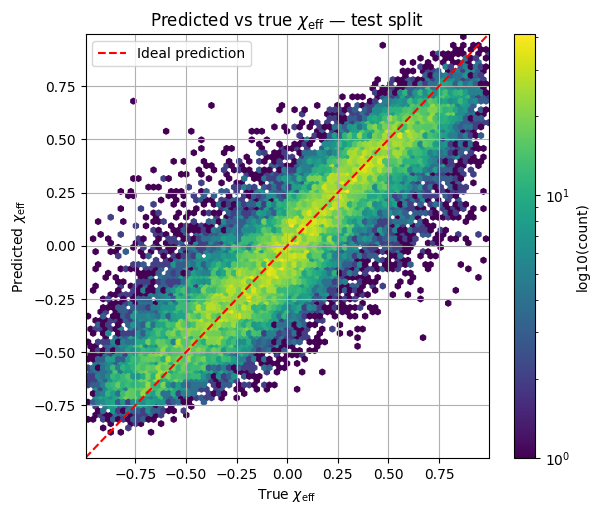

In [26]:
plt.figure(figsize=(6.5, 5.5))

hb = plt.hexbin(
    chi_true,
    chi_pred,
    gridsize=80,
    mincnt=1,
    bins="log",
)

plt.colorbar(hb, label="log10(count)")

lims = [
    min(chi_true.min(), chi_pred.min()),
    max(chi_true.max(), chi_pred.max()),
]

plt.plot(lims, lims, linestyle="--", color="red", label="Ideal prediction")
plt.xlim(lims)
plt.ylim(lims)

plt.xlabel(r"True $\chi_{\mathrm{eff}}$")
plt.ylabel(r"Predicted $\chi_{\mathrm{eff}}$")
plt.title(r"Predicted vs true $\chi_{\mathrm{eff}}$ — test split")
plt.grid(True)
plt.legend()
plt.show()

We can make a linear fit to quantify it.

- slope ≈ 1  → sin contracción sistemática
- slope < 1  → regresión hacia cero / hacia la media
- slope > 1  → expansión de los valores extremos
- intercept ≠ 0 → offset sistemático

In [24]:
slope, intercept = np.polyfit(chi_true, chi_pred, deg=1)

correlation = np.corrcoef(chi_true, chi_pred)[0, 1]

print(f"Linear fit: predicted = {slope:.4f} * true + {intercept:.4f}")
print(f"Pearson correlation: {correlation:.4f}")

Linear fit: predicted = 0.7728 * true + -0.0044
Pearson correlation: 0.8846


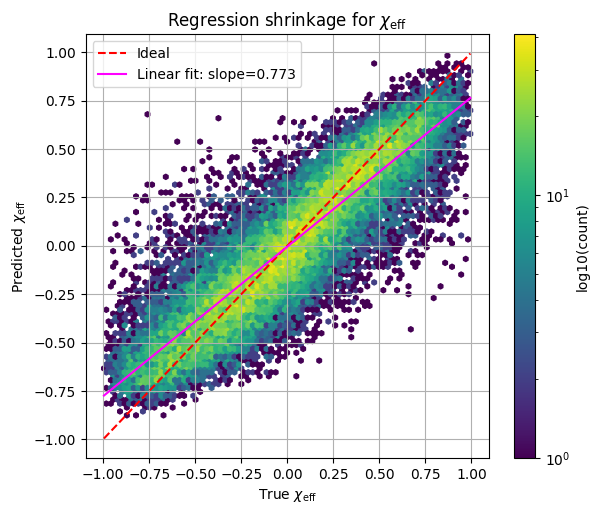

In [30]:
x_line = np.linspace(chi_true.min(), chi_true.max(), 300)

plt.figure(figsize=(6.5, 5.5))

hb = plt.hexbin(
    chi_true,
    chi_pred,
    gridsize=80,
    mincnt=1,
    bins="log",
)

plt.colorbar(hb, label="log10(count)")
plt.plot(x_line, x_line, linestyle="--", color="red", label="Ideal")
plt.plot(
    x_line,
    slope * x_line + intercept,
    linewidth=1.5,
    color="magenta",
    label=f"Linear fit: slope={slope:.3f}",
)

plt.xlabel(r"True $\chi_{\mathrm{eff}}$")
plt.ylabel(r"Predicted $\chi_{\mathrm{eff}}$")
plt.title(r"Regression shrinkage for $\chi_{\mathrm{eff}}$")
plt.grid(True)
plt.legend()
plt.show()

Also, residual vs $\chi_{eff}$

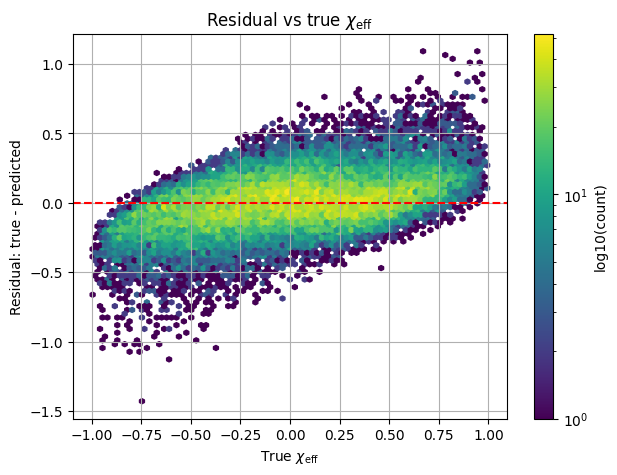

In [34]:
plt.figure(figsize=(7, 5))

hb = plt.hexbin(
    chi_true,
    chi_residual,
    gridsize=80,
    mincnt=1,
    bins="log",
)

plt.colorbar(hb, label="log10(count)")
plt.axhline(0.0, linestyle="--", color="r")

plt.xlabel(r"True $\chi_{\mathrm{eff}}$")
plt.ylabel(r"Residual: true - predicted")
plt.title(r"Residual vs true $\chi_{\mathrm{eff}}$")
plt.grid(True)
plt.show()

Metrics per bins. We use fixed bins in phys space: [-1.0, -0.75, -0.50, -0.25, 0, 0.25, 0.50, 0.75, 1.0]

In [35]:
chi_edges = np.linspace(-1.0, 1.0, 9)

chi_bin_index = np.digitize(
    chi_true,
    bins=chi_edges[1:-1],
    right=False,
)

chi_bin_rows = []

for bin_idx in range(len(chi_edges) - 1):
    mask = chi_bin_index == bin_idx
    n_bin = int(mask.sum())

    if n_bin == 0:
        continue

    residual_bin = chi_residual[mask]
    abs_error_bin = chi_abs_error[mask]
    true_bin = chi_true[mask]
    pred_bin = chi_pred[mask]

    chi_bin_rows.append({
        "bin_idx": bin_idx,
        "chi_low": chi_edges[bin_idx],
        "chi_high": chi_edges[bin_idx + 1],
        "chi_center": 0.5 * (
            chi_edges[bin_idx] + chi_edges[bin_idx + 1]
        ),
        "n_samples": n_bin,
        "true_mean": true_bin.mean(),
        "pred_mean": pred_bin.mean(),
        "bias_true_minus_pred": residual_bin.mean(),
        "median_residual": np.median(residual_bin),
        "MAE": abs_error_bin.mean(),
        "RMSE": np.sqrt(np.mean(residual_bin**2)),
        "q50_abs_error": np.quantile(abs_error_bin, 0.50),
        "q90_abs_error": np.quantile(abs_error_bin, 0.90),
        "q95_abs_error": np.quantile(abs_error_bin, 0.95),
    })

chi_true_bin_df = pd.DataFrame(chi_bin_rows)

chi_true_bin_df

,bin_idx,chi_low,chi_high,chi_center,n_samples,true_mean,pred_mean,bias_true_minus_pred,median_residual,MAE,RMSE,q50_abs_error,q90_abs_error,q95_abs_error
0,0,-1.00,-0.75,-0.875,1173,-0.834994,-0.570881,-0.264113,-0.228607,0.265187,0.319926,0.228607,0.487084,0.583270
1,1,-0.75,-0.50,-0.625,3308,-0.616360,-0.471882,-0.144478,-0.116015,0.171496,0.234385,0.125115,0.376027,0.492473
2,2,-0.50,-0.25,-0.375,4765,-0.368643,-0.307680,-0.060963,-0.047941,0.147444,0.194575,0.115820,0.313852,0.394774
3,3,-0.25,0.00,-0.125,5517,-0.122320,-0.130267,0.007947,0.015330,0.141100,0.180730,0.113770,0.297710,0.363950
4,4,0.00,0.25,0.125,5766,0.122224,0.085195,0.037029,0.028361,0.141806,0.181109,0.114924,0.299691,0.365878
5,5,0.25,0.50,0.375,4900,0.370554,0.317473,0.053081,0.032392,0.132372,0.177224,0.099991,0.284868,0.371887
6,6,0.50,0.75,0.625,3384,0.613601,0.482355,0.131246,0.104471,0.158986,0.214987,0.116950,0.353202,0.464128
7,7,0.75,1.00,0.875,1187,0.834995,0.600319,0.234676,0.196927,0.238263,0.297091,0.196927,0.480783,0.596393


Here, the column ```bias_true_minus_pred```, means

- positive: too low pred.
- negative: too high pred.

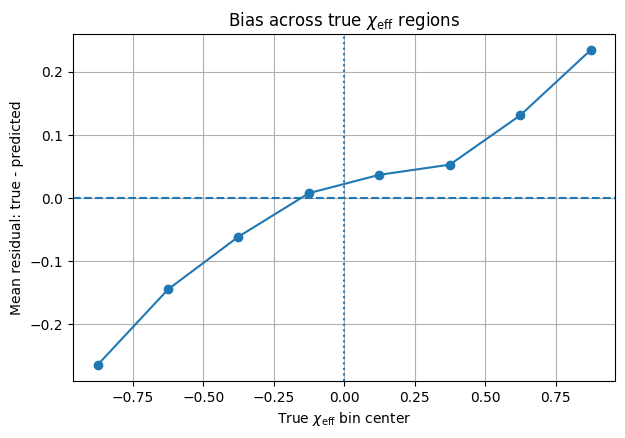

In [36]:
plt.figure(figsize=(7, 4.5))

plt.plot(
    chi_true_bin_df["chi_center"],
    chi_true_bin_df["bias_true_minus_pred"],
    marker="o",
)

plt.axhline(0.0, linestyle="--")
plt.axvline(0.0, linestyle=":")

plt.xlabel(r"True $\chi_{\mathrm{eff}}$ bin center")
plt.ylabel("Mean residual: true - predicted")
plt.title(r"Bias across true $\chi_{\mathrm{eff}}$ regions")
plt.grid(True)
plt.show()

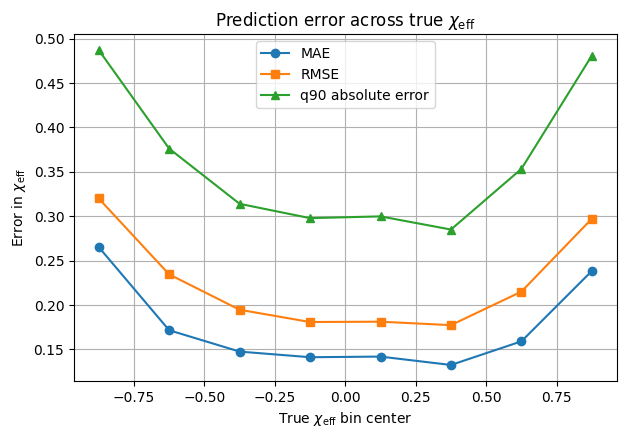

In [37]:
plt.figure(figsize=(7, 4.5))

plt.plot(
    chi_true_bin_df["chi_center"],
    chi_true_bin_df["MAE"],
    marker="o",
    label="MAE",
)

plt.plot(
    chi_true_bin_df["chi_center"],
    chi_true_bin_df["RMSE"],
    marker="s",
    label="RMSE",
)

plt.plot(
    chi_true_bin_df["chi_center"],
    chi_true_bin_df["q90_abs_error"],
    marker="^",
    label="q90 absolute error",
)

plt.xlabel(r"True $\chi_{\mathrm{eff}}$ bin center")
plt.ylabel(r"Error in $\chi_{\mathrm{eff}}$")
plt.title(r"Prediction error across true $\chi_{\mathrm{eff}}$")
plt.grid(True)
plt.legend()
plt.show()

Checking if the error at edges are related to low populated regions. Checking number of samples...

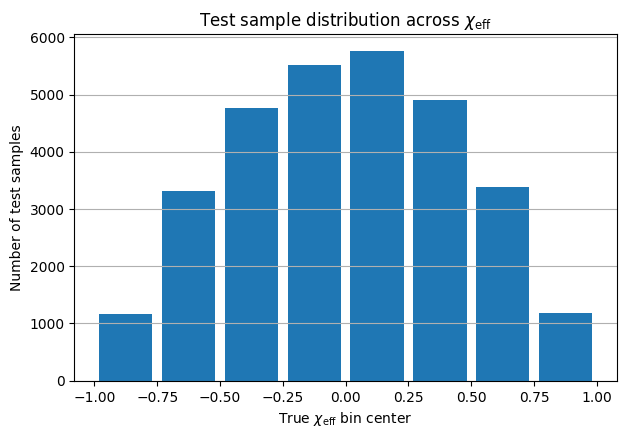

In [38]:
plt.figure(figsize=(7, 4.5))

plt.bar(
    chi_true_bin_df["chi_center"],
    chi_true_bin_df["n_samples"],
    width=np.diff(chi_edges) * 0.85,
)

plt.xlabel(r"True $\chi_{\mathrm{eff}}$ bin center")
plt.ylabel("Number of test samples")
plt.title(r"Test sample distribution across $\chi_{\mathrm{eff}}$")
plt.grid(True, axis="y")
plt.show()

Moreover, the normalized error in the chi_eff range (approx. [-1, 1])

In [40]:
CHI_RANGE = 2.0

chi_summary_relative = pd.DataFrame({
    "metric": [
        "MAE",
        "RMSE",
        "q50_abs_error",
        "q90_abs_error",
        "q95_abs_error",
        "q99_abs_error",
    ],
    "value": [
        chi_abs_error.mean(),
        np.sqrt(np.mean(chi_squared_error)),
        np.quantile(chi_abs_error, 0.50),
        np.quantile(chi_abs_error, 0.90),
        np.quantile(chi_abs_error, 0.95),
        np.quantile(chi_abs_error, 0.99),
    ],
})

chi_summary_relative["fraction_of_full_range"] = (
    chi_summary_relative["value"] / CHI_RANGE
)


chi_summary_relative

,metric,value,fraction_of_full_range
0,MAE,0.154883,0.077442
1,RMSE,0.205475,0.102737
2,q50_abs_error,0.119779,0.059890
3,q90_abs_error,0.330503,0.165251
4,q95_abs_error,0.420228,0.210114
5,q99_abs_error,0.623012,0.311506


For example, q90 = 0.3305, represents approx.

0.3305 / 2 ≈ 16.5% of full range.

Comparing extremes and central region.

In [41]:
region_masks = {
    "negative_extreme": chi_true < -0.5,
    "negative_moderate": (chi_true >= -0.5) & (chi_true < -0.2),
    "central": np.abs(chi_true) <= 0.2,
    "positive_moderate": (chi_true > 0.2) & (chi_true <= 0.5),
    "positive_extreme": chi_true > 0.5,
}

region_rows = []

for region_name, mask in region_masks.items():
    residual_region = chi_residual[mask]
    abs_error_region = chi_abs_error[mask]

    region_rows.append({
        "region": region_name,
        "n_samples": int(mask.sum()),
        "true_mean": chi_true[mask].mean(),
        "pred_mean": chi_pred[mask].mean(),
        "bias_true_minus_pred": residual_region.mean(),
        "MAE": abs_error_region.mean(),
        "RMSE": np.sqrt(np.mean(residual_region**2)),
        "q90_abs_error": np.quantile(abs_error_region, 0.90),
        "q95_abs_error": np.quantile(abs_error_region, 0.95),
    })

chi_region_df = pd.DataFrame(region_rows)

chi_region_df

,region,n_samples,true_mean,pred_mean,bias_true_minus_pred,MAE,RMSE,q90_abs_error,q95_abs_error
0,negative_extreme,4481,-0.673592,-0.497797,-0.175795,0.196022,0.259516,0.417765,0.527045
1,negative_moderate,5852,-0.341780,-0.289172,-0.052608,0.146966,0.192912,0.311969,0.391858
2,central,9062,0.002059,-0.024122,0.026181,0.141242,0.180639,0.297319,0.364080
3,positive_moderate,6034,0.343134,0.293818,0.049316,0.133795,0.177520,0.288654,0.371542
4,positive_extreme,4571,0.671093,0.512988,0.158105,0.179573,0.239034,0.396306,0.512570


### Observations

The effective-spin predictor exhibits a clear regression-to-the-mean effect. The fitted relation between predicted and true values has slope 0.773 and negligible intercept, indicating that the model preserves ordering but systematically compresses the dynamic range. The bias changes sign across zero, becoming negative for large negative spins and positive for large positive spins. Error dispersion also increases toward the physical extremes: the q90 absolute error rises from approximately 0.30 near the center to approximately 0.48 for |chi_eff| > 0.75.